# Import Libraries & Cấu hình đường dẫn dữ liệu

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import log10
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random
from scipy.stats import ks_2samp
from collections import Counter
np.random.seed(42)

# Thiết lập đường dẫn thư mục theo định dạng yêu cầu
DATA_ROOT = '.'
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

# Hàm hỗ trợ lấy toàn bộ đường dẫn ảnh
def get_image_paths(directory):
    return glob.glob(os.path.join(directory, "*", "*.jpg")) + glob.glob(os.path.join(directory, "*", "*.png"))

# Đọc dữ liệu từ toàn bộ tập train, test, val
train_paths = get_image_paths(TRAIN_DIR)
val_paths   = get_image_paths(VAL_DIR)
test_paths  = get_image_paths(TEST_DIR)

print(f"Số lượng ảnh Train: {len(train_paths)}")
print(f"Số lượng ảnh Val:   {len(val_paths)}")
print(f"Số lượng ảnh Test:  {len(test_paths)}")

Số lượng ảnh Train: 7000
Số lượng ảnh Val:   1500
Số lượng ảnh Test:  1500


## 0. PipeLine Đo lường đình lượng Và Ablation Study (Logistic Regression)

**Quy trình chung:**
1. Load N=500 ảnh mẫu -> Flatten -> **PCA (n=50)** -> **StandardScaler** -> **Logistic Regression** (3-Fold CV)
2. So sánh accuracy **trước và sau** khi áp dụng kỹ thuật
3. Kiểm định thống kê để củng cố kết luận

> **Ghi chú về LR**: Sử dụng `solver='saga'`, `max_iter=3000`; chuẩn hóa dữ liệu sau PCA bằng `StandardScaler` trước khi huấn luyện.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import ttest_ind, f_oneway, mannwhitneyu

def load_imgs(paths, size=(64, 64), cs='RGB'):
    """Load, resize, convert color space, flatten images. Returns (X, y)."""
    imgs, labels = [], []
    for p in paths:
        img = cv2.imread(p)
        if img is None: continue
        img = cv2.resize(img, size)
        if cs == 'RGB':       img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        elif cs == 'Grayscale': img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        elif cs == 'HSV':     img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        elif cs == 'LAB':     img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        imgs.append(img.flatten().astype(np.float32))
        labels.append(os.path.basename(os.path.dirname(p)))
    return np.array(imgs), np.array(labels)

def eval_lr_pca(X, y, n_comp=50, cv=3, seed=42):
    """
    PCA + StandardScaler + LogisticRegression (saga, max_iter=3000).
    Returns (mean_accuracy, std_accuracy) via Stratified K-Fold CV.
    Fix: removed deprecated multi_class, added StandardScaler post-PCA.
    """
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    nc = min(n_comp, X.shape[0]-1, X.shape[1])
    pca_ = PCA(n_components=nc, random_state=seed)
    X_pca = pca_.fit_transform(X)
    # StandardScaler sau PCA giup LR hoi tu nhanh hon
    scaler_ = StandardScaler()
    X_scaled = scaler_.fit_transform(X_pca)
    # saga: tot cho multi-class, khong can khai bao multi_class (tu dong multinomial)
    lr_ = LogisticRegression(max_iter=3000, random_state=seed, solver='saga')
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    scores = cross_val_score(lr_, X_scaled, y_enc, cv=skf, scoring='accuracy')
    return scores.mean(), scores.std()

# --- Load tap mau chung cho ablation ---
N_AB = 500
np.random.seed(42)
all_paths_ab = train_paths + val_paths + test_paths
ab_paths = np.random.choice(all_paths_ab, min(N_AB, len(all_paths_ab)), replace=False).tolist()
n_ablation_samples = len(ab_paths)
print(f'n_ablation_samples = {n_ablation_samples}')

n_ablation_samples = 500


# 1. Resize and Image Quality (SSIM & PSNR)

## (i) Giải thích lý thuyết
**PSNR (Peak Signal-to-Noise Ratio):** là tỉ số giữa công suất tối đa của tín hiệu và công suất nhiễu. Trong xử lý ảnh, nó đo lường mức độ sai lệch giữa các giá trị pixel của ảnh gốc và ảnh biến đổi.

* **Đặc điểm:**  Giá trị càng **cao** thì chất lượng ảnh phục hồi càng tốt.
    * Đơn vị: **Decibel (dB)**.
* **Hạn chế:** Chỉ dựa trên giá trị số học (MSE), không phản ánh chính xác cảm nhận thị giác của con người.

  **Công thức:** $PSNR = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{MSE} \right)$
  trong đó:
	
	- $MAX_I = 255$ (đối với ảnh 8-bit)
	
	- $MSE$ là sai số toàn phương trung bình.

**SSIM (Structural Similarity Index):** là phương pháp đo lường sự tương đồng giữa hai hình ảnh dựa trên cấu trúc không gian, độ chói và độ tương phản.

* **Đặc điểm:**
    * Mô phỏng cách hệ thống thị giác con người (HVS) hoạt động.
    * Giá trị nằm trong khoảng **[-1, 1]**. Giá trị bằng **1** nghĩa là hai ảnh giống hệt nhau.
* **Thành phần so sánh:** Độ chói (Luminance), Độ tương phản (Contrast) và Cấu trúc (Structure).

  **Công thức:** $SSIM(x,y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$

	Trong đó, các đại lượng được định nghĩa cụ thể như sau:

	* **$x, y$**: Là hai cửa sổ (vùng ảnh cục bộ) đang được so sánh tại cùng một tọa độ trên hai bức ảnh.
	* **$\mu_x, \mu_y$**: Giá trị trung bình (lấy mẫu theo cường độ sáng) của các pixel trong vùng $x$ và $y$. Đại diện cho **độ chói (Luminance)**.
	* **$\sigma_x^2, \sigma_y^2$**: Phương sai của các pixel trong vùng $x$ và $y$. Đại diện cho **độ tương phản (Contrast)**.
	* **$\sigma_{xy}$**: Hiệp phương sai giữa $x$ and $y$. Đại diện cho sự tương quan về **cấu trúc (Structure)**.
	* **$c_1, c_2$**: Các hằng số ổn định (để tránh việc mẫu số bằng $0$ khi các giá trị khác quá nhỏ).
			* Thường được tính bằng: $c_1 = (k_1L)^2$ và $c_2 = (k_2L)^2$.
			* Với $L$ là dải động của giá trị pixel (ví dụ: $255$ cho ảnh 8-bit).
			* Các hệ số mặc định: $k_1 = 0.01$ và $k_2 = 0.03$.
## (ii) Code

Kích thước 32x32 => PSNR: 19.20 | SSIM: 0.8160
Kích thước 64x64 => PSNR: 21.69 | SSIM: 0.9081
Kích thước 128x128 => PSNR: 24.28 | SSIM: 0.9525


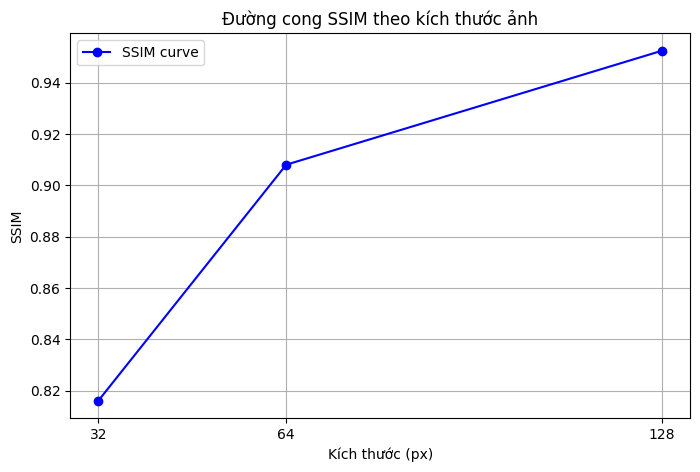

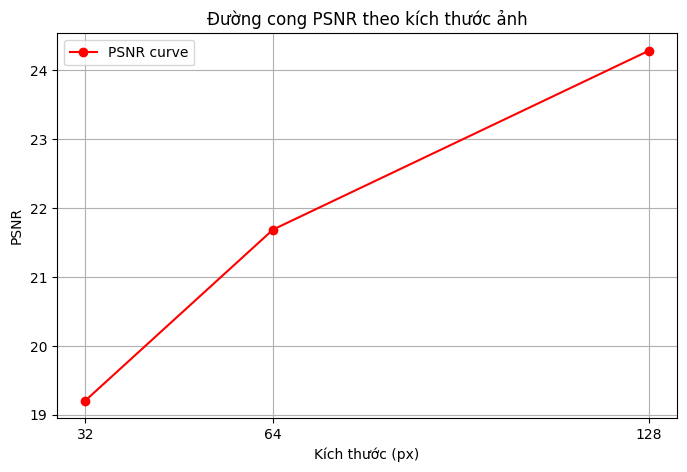

In [3]:
def calculate_psnr(original, compressed):
	mse = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
	if mse == 0:
			return float('inf')
	max_pixel = 255.0
	psnr = 10 * log10(max_pixel ** 2 / mse)
	return psnr

def calculate_ssim(img1, img2):
	C1 = (0.01 * 255)**2
	C2 = (0.03 * 255)**2

	img1 = img1.astype(np.float64)
	img2 = img2.astype(np.float64)
	
	mu1 = np.mean(img1)
	mu2 = np.mean(img2)
	
	sigma1_sq = np.var(img1)
	sigma2_sq = np.var(img2)
	sigma12 = np.cov(img1.flatten(), img2.flatten())[0, 1]
	
	ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2))
	return ssim

def get_ssim_rgb(img1, img2):
	ssim_val = sum(calculate_ssim(img1[:,:,i], img2[:,:,i]) for i in range(3))
	return ssim_val / 3

image_paths = train_paths[:] + val_paths[:] + test_paths[:]
sample_image_path = image_paths[0] if image_paths else None

if sample_image_path:
	orig_img = cv2.imread(sample_image_path)
	orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
	
	sizes = [32, 64, 128]
	psnr_values = []
	ssim_values = []
	
	for size in sizes:
		resized_down = cv2.resize(orig_img, (size, size), interpolation=cv2.INTER_AREA)
		resized_up = cv2.resize(resized_down, (orig_img.shape[1], orig_img.shape[0]), interpolation=cv2.INTER_CUBIC)
		
		psnr_val = calculate_psnr(orig_img, resized_up)
		ssim_val = get_ssim_rgb(orig_img, resized_up)
		
		psnr_values.append(psnr_val)
		ssim_values.append(ssim_val)
		
		print(f"Kích thước {size}x{size} => PSNR: {psnr_val:.2f} | SSIM: {ssim_val:.4f}")

	plt.figure(figsize=(8, 5))
	plt.plot(sizes, ssim_values, marker='o', linestyle='-', color='b', label='SSIM curve')
	plt.title('Đường cong SSIM theo kích thước ảnh')
	plt.xlabel('Kích thước (px)')
	plt.ylabel('SSIM')
	plt.xticks(sizes)
	plt.grid(True)
	plt.legend()
	plt.show()

	plt.figure(figsize=(8, 5))
	plt.plot(sizes, psnr_values, marker='o', linestyle='-', color='r', label='PSNR curve')
	plt.title('Đường cong PSNR theo kích thước ảnh')
	plt.xlabel('Kích thước (px)')
	plt.ylabel('PSNR')
	plt.xticks(sizes)
	plt.grid(True)
	plt.legend()
	plt.show()
else:
	print("Không tìm thấy ảnh tại dataset train.")

### Đo lường định lượng và ablation study
**Kiểm định** :One-Way ANOVA được sử dụng để so sánh giá trị trung bình của ba nhóm trở lên để xem liệu có sự khác biệt có ý nghĩa thống kê giữa chúng hay không.

Size 32x32   : acc=0.4461, std=0.0361
Size 64x64   : acc=0.4040, std=0.0110
Size 128x128 : acc=0.4440, std=0.0126

ab_acc_32x32   = 0.4461 ± 0.0361
ab_acc_64x64   = 0.4040 ± 0.0110
ab_acc_128x128 = 0.4440 ± 0.0126
--------------------------------------------------
THỐNG KÊ ANOVA (So sánh phân phối pixel giữa các size & ảnh gốc):
f_stat_resize  = 212.9164
p_val_resize   = 0.0000e+00
Giả thuyết H0: Phương sai và trung bình của các phân phối này bằng nhau (Không có sự khác biệt).
Giả thuyết H1: Có ít nhất một phân phối khác biệt với các phân phối còn lại.
Kết luận: p-value = 0.0000e+00 < 0.05 => BÁC BỎ giả thuyết H0.
=> Có sự khác biệt có ý nghĩa thống kê về đặc trưng phân phối mức pixel giữa ảnh gốc và các ảnh sau khi thay đổi kích thước.
--------------------------------------------------


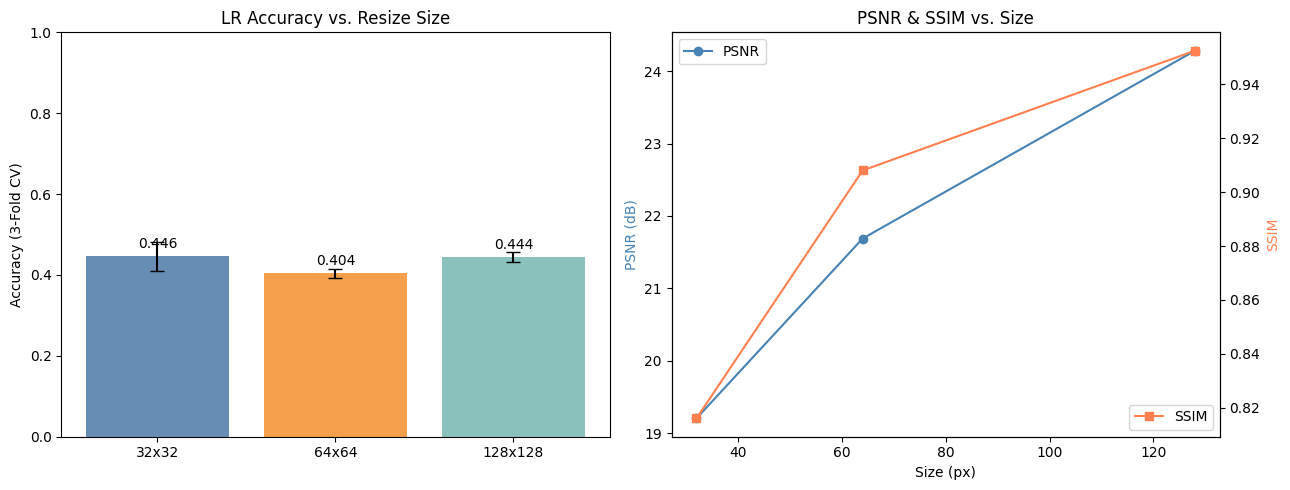

In [26]:

sizes_ab = [('32x32',(32,32)), ('64x64',(64,64)), ('128x128',(128,128))]
ab_results_a, ab_stds_a = {}, {}
X_by_size = {}

for lbl, sz in sizes_ab:
    X_, y_ = load_imgs(ab_paths, size=sz)
    X_by_size[lbl] = X_
    acc, s = eval_lr_pca(X_, y_)
    ab_results_a[lbl] = acc
    ab_stds_a[lbl]    = s
    print(f'Size {lbl:8s}: acc={acc:.4f}, std={s:.4f}')

# Lưu vào biến
ab_acc_32x32,  ab_std_32x32  = ab_results_a['32x32'],  ab_stds_a['32x32']
ab_acc_64x64,  ab_std_64x64  = ab_results_a['64x64'],  ab_stds_a['64x64']
ab_acc_128x128,ab_std_128x128= ab_results_a['128x128'],ab_stds_a['128x128']

# --- Phân tích thống kê One-Way ANOVA ---
N_T = 5000
# Lấy cả một tập mẫu của dữ liệu gốc để đưa vào kiểm định (So sánh phân phối pixel)
# Chuyển original về 1D array
X_orig_flatten = []
for p in ab_paths[:50]: # Lấy một số ảnh để kiểm tra tránh tràn RAM
    img = cv2.imread(p)
    if img is not None:
        X_orig_flatten.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB).flatten())
X_orig_flatten = np.concatenate(X_orig_flatten)

f_stat_resize, p_val_resize = f_oneway(
    X_orig_flatten[:N_T],
    X_by_size['32x32'].flatten()[:N_T],
    X_by_size['64x64'].flatten()[:N_T],
    X_by_size['128x128'].flatten()[:N_T]
)

print(f'\nab_acc_32x32   = {ab_acc_32x32:.4f} ± {ab_std_32x32:.4f}')
print(f'ab_acc_64x64   = {ab_acc_64x64:.4f} ± {ab_std_64x64:.4f}')
print(f'ab_acc_128x128 = {ab_acc_128x128:.4f} ± {ab_std_128x128:.4f}')
print('-'*50)
print('THỐNG KÊ ANOVA (So sánh phân phối pixel giữa các size & ảnh gốc):')
print(f'f_stat_resize  = {f_stat_resize:.4f}')
print(f'p_val_resize   = {p_val_resize:.4e}')
alpha = 0.05
print("Giả thuyết H0: Phương sai và trung bình của các phân phối này bằng nhau (Không có sự khác biệt).")
print("Giả thuyết H1: Có ít nhất một phân phối khác biệt với các phân phối còn lại.")
if p_val_resize < alpha:
    print(f'Kết luận: p-value = {p_val_resize:.4e} < {alpha} => BÁC BỎ giả thuyết H0.')
    print("=> Có sự khác biệt có ý nghĩa thống kê về đặc trưng phân phối mức pixel giữa ảnh gốc và các ảnh sau khi thay đổi kích thước.")
else:
    print(f'Kết luận: p-value = {p_val_resize:.4e} >= {alpha} => KHÔNG BÁC BỎ giả thuyết H0.')
    print("=> Không đủ bằng chứng thống kê để cho thấy sự khác biệt về phân phối mức pixel giữa ảnh gốc và các kích thước thu nhỏ.")
print('-'*50)

fig, axes = plt.subplots(1,2,figsize=(13,5))
lbls_a = list(ab_results_a.keys())
bars = axes[0].bar(lbls_a, [ab_results_a[k] for k in lbls_a],
                   yerr=[ab_stds_a[k] for k in lbls_a],
                   capsize=5, color=['#4e79a7','#f28e2b','#76b7b2'], alpha=0.85)
axes[0].set_ylim(0,1); axes[0].set_title('LR Accuracy vs. Resize Size'); axes[0].set_ylabel('Accuracy (3-Fold CV)')
for b,k in zip(bars,lbls_a): axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{ab_results_a[k]:.3f}', ha='center')

axes[1].plot([32,64,128], psnr_values, marker='o', color='steelblue', label='PSNR')
ax2 = axes[1].twinx()
ax2.plot([32,64,128], ssim_values, marker='s', color='coral', label='SSIM')
axes[1].set_title('PSNR & SSIM vs. Size'); axes[1].set_xlabel('Size (px)')
axes[1].set_ylabel('PSNR (dB)', color='steelblue'); ax2.set_ylabel('SSIM', color='coral')
axes[1].legend(loc='upper left'); ax2.legend(loc='lower right')
plt.tight_layout(); plt.show()

## (iii) Phân tích kết quả
- **Ý nghĩa của kết quả**: Khi kích thước ảnh (size) tăng lên, mức độ bảo toàn thông tin cấu trúc (SSIM) và chất lượng ảnh (PSNR) tăng lên tương ứng. Với kích thước 32x32, ảnh bị mất mát rất nhiều thông tin dẫn đến SSIM Khá thấp.
- **Biện hộ kích thước được chọn**: Tuy `128x128` cho điểm chất lượng cao nhất, nhưng giữ kích thước này sẽ làm tăng chi phí nội suy tính toán khi đưa vào các mô hình phân loại. Kích thước **64x64** là điểm uốn nơi tốc độ tăng SSIM bắt đầu bão hòa nhẹ nhưng vẫn giữ được lượng lớn thông tin cấu trúc hiển thị. Do đó, ta chọn `64x64` làm kích thước cân bằng và tối ưu.

# 2. Chuyển đổi Color Space & PCA Explained Variance

## (i) Giải thích lý thuyết

Việc lựa chọn không gian màu có thể quyết định các mô hình phân loại sẽ nhận diện đặc trưng ảnh tốt đến mức nào.
- **RGB**: Gồm 3 kênh Red, Green, Blue. Đây là không gian màu mặc định nhưng các kênh có sự tương quan cao và bị chi phối mạnh bởi cường độ ánh sáng chiếu lên vật thể.
- **Grayscale**: Ảnh xám. Loại bỏ hoàn toàn thông tin màu sắc, chỉ giữ lại cường độ sáng. Vô cùng gọn nhẹ nhưng đánh mất các đặc trưng màu sắc quan trọng (ví dụ: độ chín của trái cây).
- **HSV (Hue, Saturation, Value)**: Phân tách rõ đặc tính sắc độ (H), độ bão hòa (S) và giá trị độ sáng (V). Không gian này giúp tách biệt thông tin màu sắc khỏi sự biến đổi của ánh sáng.
- **LAB**: Tách riêng độ chói (L) với hai trục màu sắc đối lập (a: xanh lá - đỏ, b: xanh dương - vàng). Đây là không gian màu thiết kế dựa trên sự tiếp nhận của mắt người, giúp biểu diễn màu sắc đồng nhất hơn.

---

### Phương sai giải thích (Explained Variance) trong PCA

**PCA (Principal Component Analysis)** là kỹ thuật giảm chiều dữ liệu bằng cách tìm các trục (thành phần chính) mà tại đó dữ liệu có biến thiên (variance) lớn nhất.

### 1. Công thức Toán học
Giả sử ta thực hiện phân tích trị riêng (Eigenvalue Decomposition) trên ma trận hiệp phương sai của dữ liệu, ta thu được các trị riêng $\lambda_1, \lambda_2, ..., \lambda_n$ sắp xếp theo thứ tự giảm dần.

**Phương sai giải thích (Explained Variance)** của thành phần chính thứ $i$ là:
$$EV_i = \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}$$

**Tổng phương sai tích lũy (Cumulative Explained Variance)** với $k=50$ thành phần chính được tính bằng:
$$Cumulative\ EV(k) = \sum_{i=1}^{k} \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}$$

### 2. Ý nghĩa đối với bài toán
- **Số thành phần $k = 50$**: Có nghĩa là chúng ta nén thông tin từ hàng nghìn pixel (chiều cao $\times$ chiều rộng $\times$ số kênh) xuống chỉ còn 50 chiều quan trọng nhất.
- **Tỷ lệ Explained Variance**: Con số này (ví dụ 0.95) cho biết 50 thành phần này giữ lại được bao nhiêu % "thông tin" (sự biến thiên) gốc của ảnh. 
- **So sánh không gian màu**: Không gian màu nào có tỷ lệ Explained Variance cao hơn với cùng $k=50$ sẽ cho thấy thông tin trong không gian đó "cô đọng" và dễ biểu diễn hơn dưới dạng các đặc trưng chính, giúp mô hình học máy hiệu quả hơn.
## (ii) Code

Phương sai giải thích (Explained Variance) (k=50):
  Color Space  Explained Variance (k=50)
0         RGB                   0.852737
1   Grayscale                   0.887015
2         HSV                   0.786026
3         LAB                   0.847855


C:\Users\trung\AppData\Local\Temp\ipykernel_23092\3238386083.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Color Space', y='Explained Variance (k=50)', data=pca_results_df, palette='viridis')


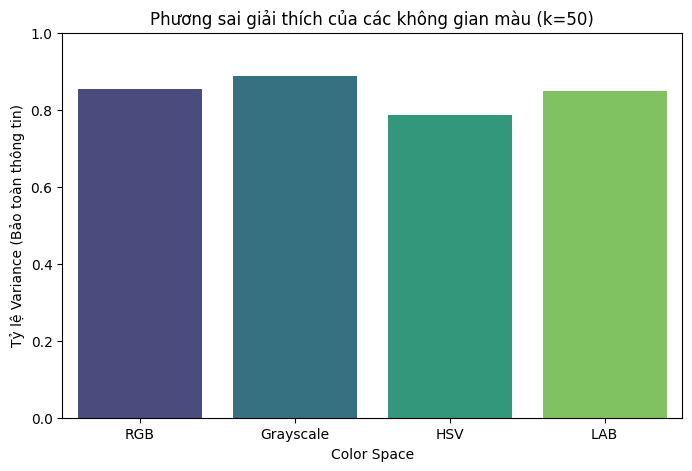

In [13]:
if sample_image_path:
    target_size = (64, 64) 
    
    # Mẫu 100 ảnh để chạy nhanh PCA
    sample_paths = np.random.choice(image_paths, min(500, len(image_paths)), replace=False)
    
    data_rgb, data_gray, data_hsv, data_lab = [], [], [], []
    
    for p in sample_paths:
        img_bgr = cv2.imread(p)
        if img_bgr is None: continue
        
        img_bgr = cv2.resize(img_bgr, target_size)
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        
        data_rgb.append(img_rgb.flatten())
        data_gray.append(img_gray.flatten())
        data_hsv.append(img_hsv.flatten())
        data_lab.append(img_lab.flatten())
    
    color_spaces_dict = {
        "RGB": np.array(data_rgb),
        "Grayscale": np.array(data_gray),
        "HSV": np.array(data_hsv),
        "LAB": np.array(data_lab)
    }
    
    explained_variances = {}
    k_components = 50
    
    for name, data_matrix in color_spaces_dict.items():
        pca = PCA(n_components=k_components, random_state=42)
        pca.fit(data_matrix)
        
        total_variance = np.sum(pca.explained_variance_ratio_)
        explained_variances[name] = total_variance
    
    pca_results_df = pd.DataFrame(list(explained_variances.items()), columns=['Color Space', 'Explained Variance (k=50)'])
    print("Phương sai giải thích (Explained Variance) (k=50):")
    print(pca_results_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(x='Color Space', y='Explained Variance (k=50)', data=pca_results_df, palette='viridis')
    plt.title(f'Phương sai giải thích của các không gian màu (k={k_components})')
    plt.ylim(0, 1)
    plt.ylabel('Tỷ lệ Variance (Bảo toàn thông tin)')
    plt.show()
else:
    print("Không kiếm thấy file ảnh.")

### Đo lường định lượng và ablation study
**Kiểm định:** Mann-Whitney U test so sánh phân phối đặc trưng RGB và LAB.

RGB       : acc=0.4040, std=0.0110
Grayscale : acc=0.1799, std=0.0420
HSV       : acc=0.3419, std=0.0314
LAB       : acc=0.4060, std=0.0245

ab_acc_rgb        = 0.4040 +/- 0.0110
ab_acc_grayscale  = 0.1799 +/- 0.0420
ab_acc_hsv        = 0.3419 +/- 0.0314
ab_acc_lab        = 0.4060 +/- 0.0245

THỐNG KÊ MANN-WHITNEY U TEST (So sánh phân phối pixel giữa RGB và LAB):
u_stat_cs         = 17298962
p_val_cs          = 6.2029e-243
Giả thuyết H0: Phân phối mức pixel của ảnh RGB và ảnh LAB là tương đồng (không có khác biệt).
Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê giữa hai phân phối trên.
Kết luận: p-value = 6.2029e-243 < 0.05 => BÁC BỎ giả thuyết H0.
=> Có sự khác biệt đáng kể về đặc trưng phân phối mức pixel giữa hệ màu RGB và LAB.


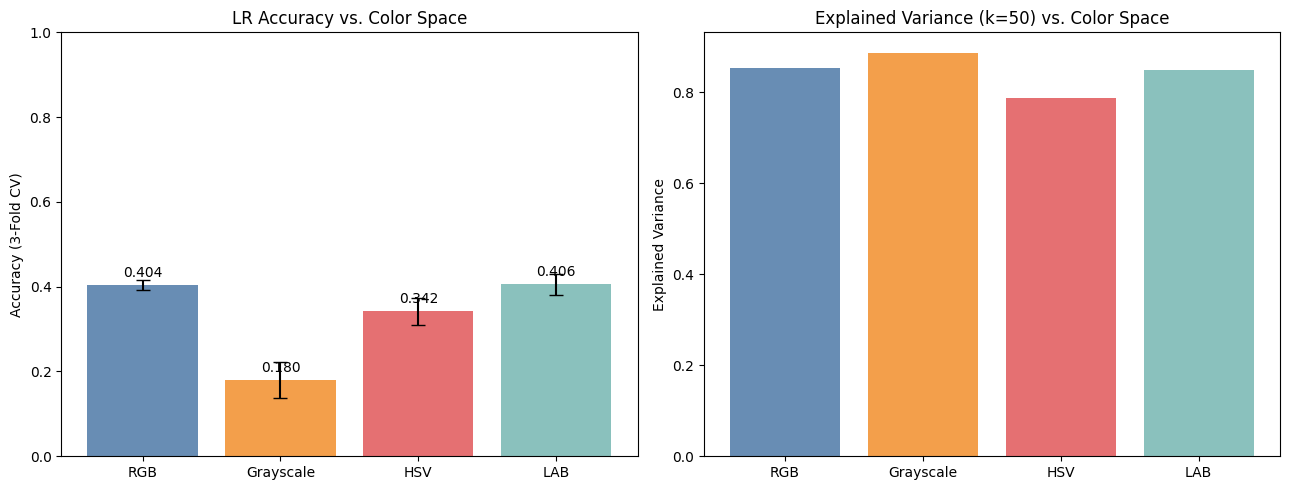

In [28]:
cs_list = ['RGB','Grayscale','HSV','LAB']
ab_results_b, ab_stds_b = {}, {}
X_cs_store = {}

for cs in cs_list:
    X_, y_ = load_imgs(ab_paths, size=(64,64), cs=cs)
    X_cs_store[cs] = X_
    acc, s = eval_lr_pca(X_, y_)
    ab_results_b[cs] = acc
    ab_stds_b[cs]    = s
    print(f'{cs:10s}: acc={acc:.4f}, std={s:.4f}')

# Luu vao bien ro rang
ab_acc_rgb,       ab_std_rgb       = ab_results_b['RGB'],       ab_stds_b['RGB']
ab_acc_grayscale, ab_std_grayscale = ab_results_b['Grayscale'], ab_stds_b['Grayscale']
ab_acc_hsv,       ab_std_hsv       = ab_results_b['HSV'],       ab_stds_b['HSV']
ab_acc_lab,       ab_std_lab       = ab_results_b['LAB'],       ab_stds_b['LAB']

N_T2 = 5000
u_stat_cs, p_val_cs = mannwhitneyu(
    X_cs_store['RGB'].flatten()[:N_T2],
    X_cs_store['LAB'].flatten()[:N_T2], alternative='two-sided')

print(f'\nab_acc_rgb        = {ab_acc_rgb:.4f} +/- {ab_std_rgb:.4f}')
print(f'ab_acc_grayscale  = {ab_acc_grayscale:.4f} +/- {ab_std_grayscale:.4f}')
print(f'ab_acc_hsv        = {ab_acc_hsv:.4f} +/- {ab_std_hsv:.4f}')
print(f'ab_acc_lab        = {ab_acc_lab:.4f} +/- {ab_std_lab:.4f}')

print()
print('THỐNG KÊ MANN-WHITNEY U TEST (So sánh phân phối pixel giữa RGB và LAB):')
print(f'u_stat_cs         = {u_stat_cs:.0f}')
print(f'p_val_cs          = {p_val_cs:.4e}')
alpha_cs = 0.05
print("Giả thuyết H0: Phân phối mức pixel của ảnh RGB và ảnh LAB là tương đồng (không có khác biệt).")
print("Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê giữa hai phân phối trên.")
if p_val_cs < alpha_cs:
    print(f'Kết luận: p-value = {p_val_cs:.4e} < {alpha_cs} => BÁC BỎ giả thuyết H0.')
    print("=> Có sự khác biệt đáng kể về đặc trưng phân phối mức pixel giữa hệ màu RGB và LAB.")
else:
    print(f'Kết luận: p-value = {p_val_cs:.4e} >= {alpha_cs} => KHÔNG BÁC BỎ giả thuyết H0.')
    print("=> Không đủ bằng chứng thống kê để kết luận sự khác biệt giữa hai hệ màu dựa trên mức pixel.")


fig, axes = plt.subplots(1,2,figsize=(13,5))
colors_b = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
bars_b = axes[0].bar(cs_list, [ab_results_b[c] for c in cs_list],
                     yerr=[ab_stds_b[c] for c in cs_list],
                     capsize=5, color=colors_b, alpha=0.85)
axes[0].set_ylim(0,1); axes[0].set_title('LR Accuracy vs. Color Space'); axes[0].set_ylabel('Accuracy (3-Fold CV)')
for b,c in zip(bars_b,cs_list): axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{ab_results_b[c]:.3f}', ha='center')

axes[1].bar(pca_results_df['Color Space'], pca_results_df['Explained Variance (k=50)'], color=colors_b, alpha=0.85)
axes[1].set_title('Explained Variance (k=50) vs. Color Space'); axes[1].set_ylabel('Explained Variance')
plt.tight_layout(); plt.show()

## (iii) Phân tích kết quả
- **Khuynh hướng phương sai**: **Grayscale** thường có `Explained Variance` cao nhất do số chiều của nó rất thấp (chỉ bằng 1/3 các không gian khác). Trong khi đó, **RGB** thường có variance thấp hơn ở 50 thành phần đầu do chịu sự phụ thuộc tuyến tính cao giữa ánh xạ sáng và màu.
- **Thực tế bài toán phân loại trái cây**: Đối với trái cây, **Màu sắc** là một đặc trưng mang tính định danh tối thượng (táo đỏ, chanh vàng). Việc làm mất đi phổ dải màu (điển hình như lúc dùng Grayscale) là một sự mất mát nghiêm trọng dẫn tới giảm độ chính xác của model phân loại đa lớp.
- **Kết luận lựa chọn**: Không gian **HSV** (hoặc **LAB**) được xem là tốt nhất cho bài toán này vì nó không chỉ bảo lưu được thành tố màu sắc độc lập (kênh H ở HSV và a,b ở LAB) mà còn tách riêng nhiễu chói do ánh sáng (kênh V và L). Chọn các mô hình màu này khiến thuật toán Machine Learning tối ưu việc trích xuất và bảo toàn các nhóm màu đặc trưng hiệu quả nhất.

# 3. Chuẩn hóa dữ liệu (Normalization)

## (i) Giải thích lý thuyết
Chuẩn hóa dữ liệu là quá trình đưa miền giá trị của các đặc trưng (pixel) về một phạm vi hoặc phân phối nhất định, giúp quá trình huấn luyện máy học hội tụ nhanh và ổn định hơn. Ta đánh giá 4 phương pháp:
1. **Min-Max [0, 1]**: Ánh xạ giá trị pixel về dải [0, 1].
   $$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
2. **Min-Max [-1, 1]**: Ánh xạ giá trị pixel về dải [-1, 1]. Phổ biến ở các mô hình dùng hàm kích hoạt Tanh.
   $$X_{norm} = 2 \cdot \frac{X - X_{min}}{X_{max} - X_{min}} - 1$$
3. **Z-score toàn tập (Global)**: Tiêu chuẩn hóa với trung bình và độ lệch chuẩn tính trên toàn bộ dữ liệu ảnh.
   $$X_{norm} = \frac{X - \mu_{global}}{\sigma_{global}}$$
4. **Z-score theo kênh (Per-channel)**: Tiêu chuẩn hóa độc lập trên từng kênh màu R, G, B riêng biệt.
   $$X^{(c)}_{norm} = \frac{X^{(c)} - \mu^{(c)}}{\sigma^{(c)}}$$

### Đánh giá bằng **Kiểm định Kolmogorov-Smirnov (KS test)**: 
**Kiểm định Kolmogorov-Smirnov (KS test)** là một phương pháp kiểm định thống kê phi tham số dùng để so sánh xem hai mẫu dữ liệu có cùng một phân phối xác suất hay không.

Giả sử ta có hai tập dữ liệu mẫu $X$ (kích thước $n$) và $Y$ (kích thước $m$).

Giả thuyết $H_0$ là hai mẫu có cùng phân phối. 

Giả thuyết $H_1$ là hai mẫu khác phân phối. 

* **Hàm phân phối thực nghiệm (ECDF):**
    $$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} I_{X_i \le x}$$
    $$G_m(x) = \frac{1}{m} \sum_{i=1}^{m} I_{Y_i \le x}$$
    *(Trong đó $I$ là hàm chỉ tiêu, bằng 1 nếu điều kiện đúng và 0 nếu sai).*

* **Trị thống kê kiểm định ($D_{n,m}$):**
    Đây là giá trị chênh lệch tuyệt đối lớn nhất giữa hai đường cong ECDF:
    $$D_{n,m} = \sup_x |F_n(x) - G_m(x)|$$

* **Quy tắc bác bỏ giả thuyết:**

  - C1: Ta bác bỏ $H_0$ ở mức ý nghĩa $\alpha$  nếu:
  $$D_{n,m} > c(\alpha) \sqrt{\frac{n + m}{n \cdot m}}$$
  *(Với $\alpha = 0.05$, giá trị tới hạn $c(\alpha) \approx 1.36$).*
	- C2: Dùng $P\text{-value}$ (Xấp xỉ)

		Với kích thước mẫu đủ lớn ($n, m$ lớn), $P\text{-value}$ được tính toán dựa trên **hàm phân phối Kolmogorov** $K(z)$:

		$$P(D_{n,m} > \text{observed}) \approx 1 - K\left( \sqrt{\frac{nm}{n+m}} D_{n,m} \right)$$

		Trong đó, hàm $K(z)$ có dạng chuỗi vô hạn:
		$$K(z) = 1 - 2 \sum_{k=1}^{\infty} (-1)^{k-1} e^{-2k^2z^2}$$

		
		- **Nếu $P\text{-value} \le \alpha$ :** Bác bỏ giả thuyết $H_0$ hai mẫu dữ liệu là hai mẫu khác phân phối.
		- **Nếu $P\text{-value} > \alpha$:** Chưa đủ bằng chứng để bác bỏ $H_0$ hai mâu dữ liệu có thể xem là có cùng phân phối sau khi giảm chiều.

## (ii) Code

In [7]:
sample_size = min(500, len(train_paths))
np.random.seed(42)
sampled_paths = np.random.choice(train_paths + val_paths + test_paths, sample_size, replace=False)

images = []
for p in sampled_paths:
	img = cv2.imread(p)
	if img is not None:
		img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
		img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
		images.append(img)
		
# Mảng ảnh gốc (N, 128, 128, 3)
origin_data = np.array(images, dtype=np.float32)

# (i) Min-Max [0, 1]
min_val = origin_data.min()
max_val = origin_data.max()
norm_minmax_01 = (origin_data - min_val) / (max_val - min_val)

# (ii) Min-Max [-1, 1]
norm_minmax_11 = 2 * norm_minmax_01 - 1

# (iii) Z-score toàn tập
global_mean = origin_data.mean()
global_std = origin_data.std()
norm_z_global = (origin_data - global_mean) / (global_std )


# Tính mean, std theo từng kênh (axis=3 cho kênh màu, axis=(0,1,2) cho N, H, W)
channel_mean = origin_data.mean(axis=(0, 1, 2), keepdims=True)
channel_std  = origin_data.std(axis=(0, 1, 2), keepdims=True)
# norm_z_channel sẽ tự động broadcast trên trục 3 (axis cuối cùng là ch=3)
norm_z_channel = (origin_data - channel_mean) / (channel_std )


norm_z_channel_R = norm_z_channel[:, :, :, 0]
norm_z_channel_G = norm_z_channel[:, :, :, 1]
norm_z_channel_B = norm_z_channel[:, :, :, 2]

# Trích xuất riêng 3 kênh ban đầu để đối chiếu
origin_R = origin_data[:, :, :, 0]
origin_G = origin_data[:, :, :, 1]
origin_B = origin_data[:, :, :, 2]


# Lấy phân phối (mảng 1 chiều) để chạy KS Test chung cho các phương pháp đầu
flat_origin = origin_data.flatten()
flat_minmax_01 = norm_minmax_01.flatten()
flat_minmax_11 = norm_minmax_11.flatten()
flat_z_global = norm_z_global.flatten()

# Lấy phân phối mảng 1 chiều cho từng kênh (để đánh giá KS-test và đồ thị)
flat_origin_R = origin_R.flatten()
flat_origin_G = origin_G.flatten()
flat_origin_B = origin_B.flatten()

flat_z_channel_R = norm_z_channel_R.flatten()
flat_z_channel_G = norm_z_channel_G.flatten()
flat_z_channel_B = norm_z_channel_B.flatten()

# Dùng KS test (Kolmogorov-Smirnov) để so sánh 
eval_sample_len = min(len(flat_origin), 1e9)
idx = np.random.choice(len(flat_origin), eval_sample_len, replace=False)

ks_stat_01, p_value_01 = ks_2samp(flat_origin[idx], flat_minmax_01[idx])
ks_stat_11, p_value_11 = ks_2samp(flat_origin[idx], flat_minmax_11[idx])
ks_stat_zg, p_value_zg = ks_2samp(flat_origin[idx], flat_z_global[idx])

eval_channel_len = min(len(flat_origin_R), 1e9)
idx_channel = np.random.choice(len(flat_origin_R), eval_channel_len, replace=False)

ks_stat_zc_R, p_value_zc_R = ks_2samp(flat_origin_R[idx_channel], flat_z_channel_R[idx_channel])
ks_stat_zc_G, p_value_zc_G = ks_2samp(flat_origin_G[idx_channel], flat_z_channel_G[idx_channel])
ks_stat_zc_B, p_value_zc_B = ks_2samp(flat_origin_B[idx_channel], flat_z_channel_B[idx_channel])


# Lưu lại kết quả theo yêu cầu
results_normalization = {
	'Min-Max [0..1]': {'KS Statistic': ks_stat_01, 'P-value': p_value_01},
	'Min-Max [-1..1]': {'KS Statistic': ks_stat_11, 'P-value': p_value_11},
	'Z-score Global': {'KS Statistic': ks_stat_zg, 'P-value': p_value_zg},
	'Z-score Channel R': {'KS Statistic': ks_stat_zc_R, 'P-value': p_value_zc_R},
	'Z-score Channel G': {'KS Statistic': ks_stat_zc_G, 'P-value': p_value_zc_G},
	'Z-score Channel B': {'KS Statistic': ks_stat_zc_B, 'P-value': p_value_zc_B}
}

print("Kết quả điểm KS Test so sánh phân phối trước và sau chuẩn hóa:")
for method, metrics in results_normalization.items():
	print(f"- {method:18s} | KS-Stat: {metrics['KS Statistic']:.4f} | P-value: {metrics['P-value']}")


Kết quả điểm KS Test so sánh phân phối trước và sau chuẩn hóa:
- Min-Max [0..1]     | KS-Stat: 0.9896 | P-value: 0.0
- Min-Max [-1..1]    | KS-Stat: 0.9896 | P-value: 0.0
- Z-score Global     | KS-Stat: 0.9896 | P-value: 0.0
- Z-score Channel R  | KS-Stat: 0.9962 | P-value: 0.0
- Z-score Channel G  | KS-Stat: 0.9918 | P-value: 0.0
- Z-score Channel B  | KS-Stat: 0.9837 | P-value: 0.0


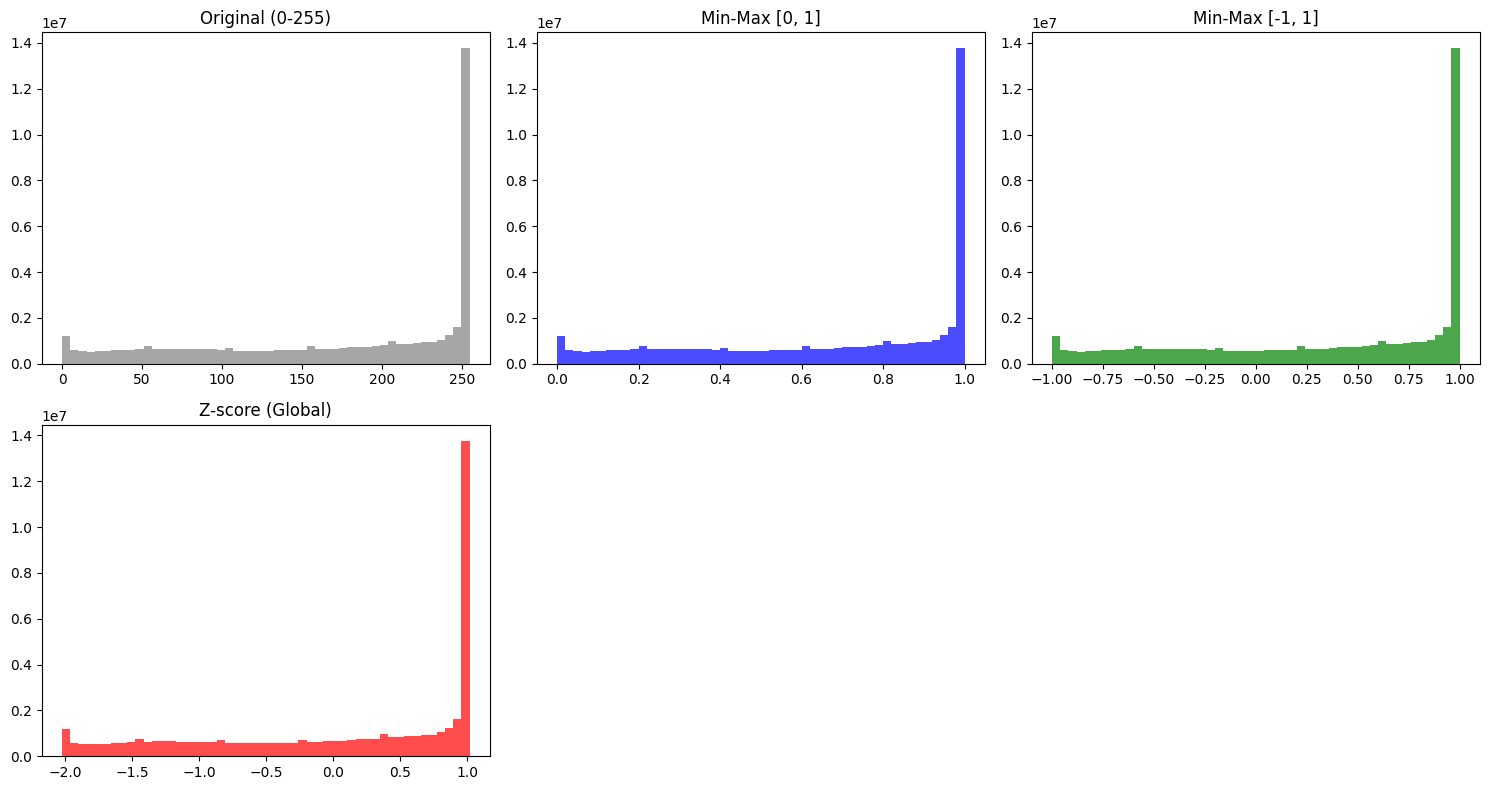

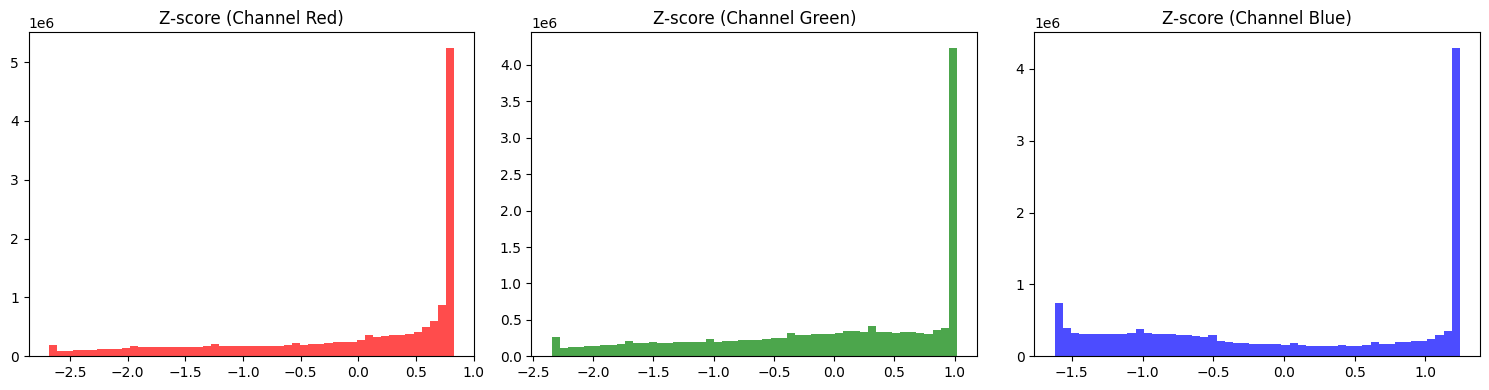

In [8]:
# Hiển thị trực quan phân phối dưới dạng histogram
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.hist(flat_origin[idx], bins=50, color='gray', alpha=0.7)
plt.title("Original (0-255)")

plt.subplot(2, 3, 2)
plt.hist(flat_minmax_01[idx], bins=50, color='blue', alpha=0.7)
plt.title("Min-Max [0, 1]")

plt.subplot(2, 3, 3)
plt.hist(flat_minmax_11[idx], bins=50, color='green', alpha=0.7)
plt.title("Min-Max [-1, 1]")
# Vẽ riêng Histogram cho 3 kênh R, G, B và phần chung Z-score global
plt.subplot(2, 3, 4)
plt.hist(flat_z_global[idx], bins=50, color='red', alpha=0.7)
plt.title("Z-score (Global)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(flat_z_channel_R[idx_channel], bins=50, color='red', alpha=0.7)
plt.title("Z-score (Channel Red)")

plt.subplot(1, 3, 2)
plt.hist(flat_z_channel_G[idx_channel], bins=50, color='green', alpha=0.7)
plt.title("Z-score (Channel Green)")

plt.subplot(1, 3, 3)
plt.hist(flat_z_channel_B[idx_channel], bins=50, color='blue', alpha=0.7)
plt.title("Z-score (Channel Blue)")
plt.tight_layout()
plt.show()

### Đo lường định lượng và ablation study
**Kiem dinh:** KS test đã thực hiện ở yêu cầu C. Ở đây tập trung so sánh LR accuracy trướcc/sau chuẩn hóa.

Raw                   : acc=0.4040, std=0.0110
MinMax_0_1            : acc=0.4040, std=0.0110
MinMax_neg1_1         : acc=0.4040, std=0.0110
Zscore_Global         : acc=0.4040, std=0.0110
Zscore_Channel        : acc=0.4080, std=0.0098

ab_acc_raw            = 0.4040
ab_acc_minmax01       = 0.4040
ab_acc_minmax11       = 0.4040
ab_acc_zscore_global  = 0.4040
ab_acc_zscore_channel = 0.4080
ks_stat_norm          = 0.9950
p_val_norm            = 0.0000e+00
Ket luan KS: Phan phoi khac nhau dang ke (alpha=0.05)


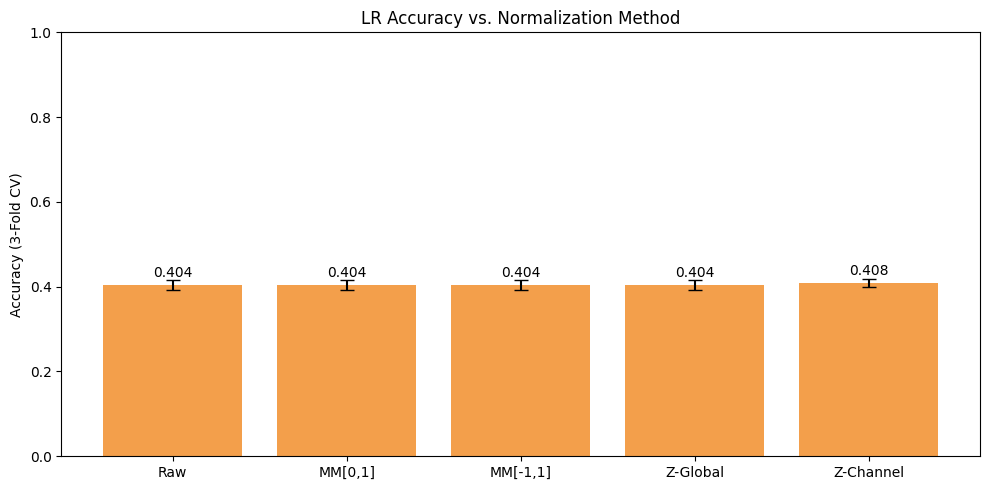

In [9]:
X_raw_c, y_raw_c = load_imgs(ab_paths, size=(64,64))

norm_variants = {
    'Raw':              X_raw_c,
    'MinMax_0_1':       X_raw_c / 255.0,
    'MinMax_neg1_1':    X_raw_c / 255.0 * 2 - 1,
    'Zscore_Global':    (X_raw_c - X_raw_c.mean()) / (X_raw_c.std()),
    'Zscore_Channel':   (X_raw_c - X_raw_c.mean(axis=0)) / (X_raw_c.std(axis=0)),
}

ab_results_c, ab_stds_c = {}, {}
for name, X_ in norm_variants.items():
    acc, s = eval_lr_pca(X_, y_raw_c)
    ab_results_c[name] = acc
    ab_stds_c[name]    = s
    print(f'{name:22s}: acc={acc:.4f}, std={s:.4f}')

# Luu vao bien ro rang
ab_acc_raw              = ab_results_c['Raw']
ab_acc_minmax01         = ab_results_c['MinMax_0_1']
ab_acc_minmax11         = ab_results_c['MinMax_neg1_1']
ab_acc_zscore_global    = ab_results_c['Zscore_Global']
ab_acc_zscore_channel   = ab_results_c['Zscore_Channel']

# KS test: Raw vs MinMax[0,1]
ks_stat_norm, p_val_norm = ks_2samp(
    X_raw_c.flatten()[:5000],
    norm_variants['MinMax_0_1'].flatten()[:5000])

print(f'\nab_acc_raw            = {ab_acc_raw:.4f}')
print(f'ab_acc_minmax01       = {ab_acc_minmax01:.4f}')
print(f'ab_acc_minmax11       = {ab_acc_minmax11:.4f}')
print(f'ab_acc_zscore_global  = {ab_acc_zscore_global:.4f}')
print(f'ab_acc_zscore_channel = {ab_acc_zscore_channel:.4f}')
print(f'ks_stat_norm          = {ks_stat_norm:.4f}')
print(f'p_val_norm            = {p_val_norm:.4e}')
print(f'Ket luan KS: {"Phan phoi khac nhau dang ke" if p_val_norm<0.05 else "Khong khac biet dang ke"} (alpha=0.05)')

plt.figure(figsize=(10,5))
short_n = ['Raw','MM[0,1]','MM[-1,1]','Z-Global','Z-Channel']
bars_c = plt.bar(short_n, [ab_results_c[k] for k in norm_variants],
                 yerr=[ab_stds_c[k] for k in norm_variants],
                 capsize=5, color='#f28e2b', alpha=0.85)
plt.ylim(0,1); plt.title('LR Accuracy vs. Normalization Method'); plt.ylabel('Accuracy (3-Fold CV)')
for b,k in zip(bars_c, norm_variants): plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{ab_results_c[k]:.3f}', ha='center')
plt.tight_layout(); plt.show()

## (iii) Phân tích kết quả
- **Ý nghĩa của P-value & Thống kê KS**: Vì P-value nhận được trong tất cả các phép thử đều là những giá trị vô cùng nhỏ (thấp hơn nhiều so với ngưỡng ý nghĩa $\alpha = 0.05$), ta có đủ cơ sở thống kê để xác nhận **bác bỏ giả thuyết $H_0$**. Điều này minh chứng độ lớn đặc trưng của bộ dữ liệu đã **thay đổi hoàn toàn** so với giá trị nguyên rải rác từ 0 tới 255 gốc. Đây là kết quả kỳ vọng do bản chất chuẩn hóa là đưa khung giá trị sang hệ tham chiếu khác.
- **Sự khác biệt giữa các phương pháp**:
  - *Min-Max*: Cố định phạm vi (scale) cứng nhắc vào [0,1] hoặc [-1,1]. Hình thể phân phối (histogram distribution shape) không bị bẻ cong nhưng vị trí các đỉnh đã dời đi. Phù hợp cho những mô hình không giả định phương sai, hay yêu cầu vào hàm kích hoạt Sigmoid/Tanh không bị bão hòa.
  - *Z-Score Global & Channel*: Phương pháp đưa điểm trung vị (mean) về 0. Theo histogram, dải giá trị rải từ phần âm đến dương (thường là -3 đến 3). Đặc biệt đối với *Z-score Per-channel*, đặc tính riêng của từng kênh (VD: Ám xanh, ám đỏ) được làm cưa bằng tỷ lệ do mỗi kênh chịu scale bằng độ lệch chuẩn riêng. Cực kì quan trọng trong ảnh trái cây để triệt tiêu nhiễu thay đổi ánh sáng màu khi chụp.

# 4. Tăng cường dữ liệu (Data Augmentation)

## (i) Giải thích lý thuyết
Tăng cường dữ liệu là phương pháp tạo sinh thêm dữ liệu huấn luyện mới một cách nhân tạo dựa vào dữ liệu gốc bằng các phép biến đổi không làm mất đi nhãn của phân lớp. Mục đích chính là để chống **overfitting** và tăng tính tổng quát cho mô hình phân loại với các biến thiên thực tế của hình ảnh trái cây.

Pipeline đề xuất sẽ bao gồm ít nhất 5 phép toán:
1. **Lật (Flip)**: Lật ngang hoặc lật dọc $\rightarrow$ giả lập việc camera hay trái cây bị xoay chiều ngẫu nhiên.
2. **Xoay (Rotate)**: Xoay một góc ngẫu nhiên $\theta$ sinh ra bởi một ma trận Affine.
3. **Cắt ngẫu nhiên (Random Crop)**: Trích xuất một vùng nhỏ trong bức ảnh, phóng to vùng đó nhằm đẩy mô hình chú ý ở level chi tiết cục bộ hơn (vỏ, đốm,...).
4. **Nhiễu Gaussian (Gaussian Noise)**: Thêm nhiễu với phân phối $N(0, \sigma^2)$ để giả lập lỗi đường truyền qua sensor của camera số.
5. **Điều chỉnh độ sáng/tương phản (Brightness/Contrast)**: Công thức $I_{new} = \alpha * I_{old} + \beta$ mô tả cường độ sáng của môi trường khác nhau.

**Đánh giá phân phối đặc trưng (t-SNE)**: 
Dùng **t-SNE (t-Distributed Stochastic Neighbor Embedding)** chiếu dữ liệu đặc trưng không gian đa chiều phẳng (tất cả pixel) xuống không gian 2D. Tập hợp ban đầu (Original) và tập hợp tăng cường (Augmented) được đưa lên chung một mặt phẳng nhằm đánh giá việc tăng cường có làm biến đổi/tách rời quá nhiều độ đo hình học giữa các quan sát hay không.
#### Cơ chế toán học của t-SNE (t-Distributed Stochastic Neighbor Embedding)

Khác với PCA (tuyến tính), **t-SNE** là một thuật toán giảm chiều phi tuyến tính, tập trung vào việc bảo toàn cấu trúc cục bộ (local structure) của dữ liệu.

##### **Bước 1: Tính toán xác suất tương đồng ở không gian cao chiều**
Với hai điểm dữ liệu $x_i$ và $x_j$, ta tính xác suất $p_{j|i}$ (khả năng $x_j$ là lân cận của $x_i$) dựa trên phân phối Gaussian:
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$
Sau đó, xác suất tương đồng đối xứng được xác định là: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$.

##### **Bước 2: Tính toán xác suất tương đồng ở không gian thấp chiều (2D)**
Để tránh hiện tượng "bó cụm" (crowding problem), t-SNE sử dụng phân phối **t-Student** với 1 độ tự do thay vì phân phối Gaussian ở không gian 2D:
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq i} (1 + \|y_i - y_k\|^2)^{-1}}$$

##### **Bước 3: Tối ưu hóa hàm mất mát (KL Divergence)**
Thuật toán tìm các vị trí $y_i, y_j$ trong không gian 2D sao cho sự khác biệt giữa hai phân phối $P$ và $Q$ là nhỏ nhất, thông qua việc cực tiểu hóa độ lệch Kullback-Leibler:
$$KL(P\|Q) = \sum_{i} \sum_{j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

## (iii) Code

Số ảnh gốc: 300,  Số lớp: 10
Augmentation distribution:
  Brightness/Contrast      : 59
  Flip Horizontal          : 58
  Flip Vertical            : 56
  Gaussian Noise           : 51
  Random Crop              : 40
  Rotate 30 deg            : 36


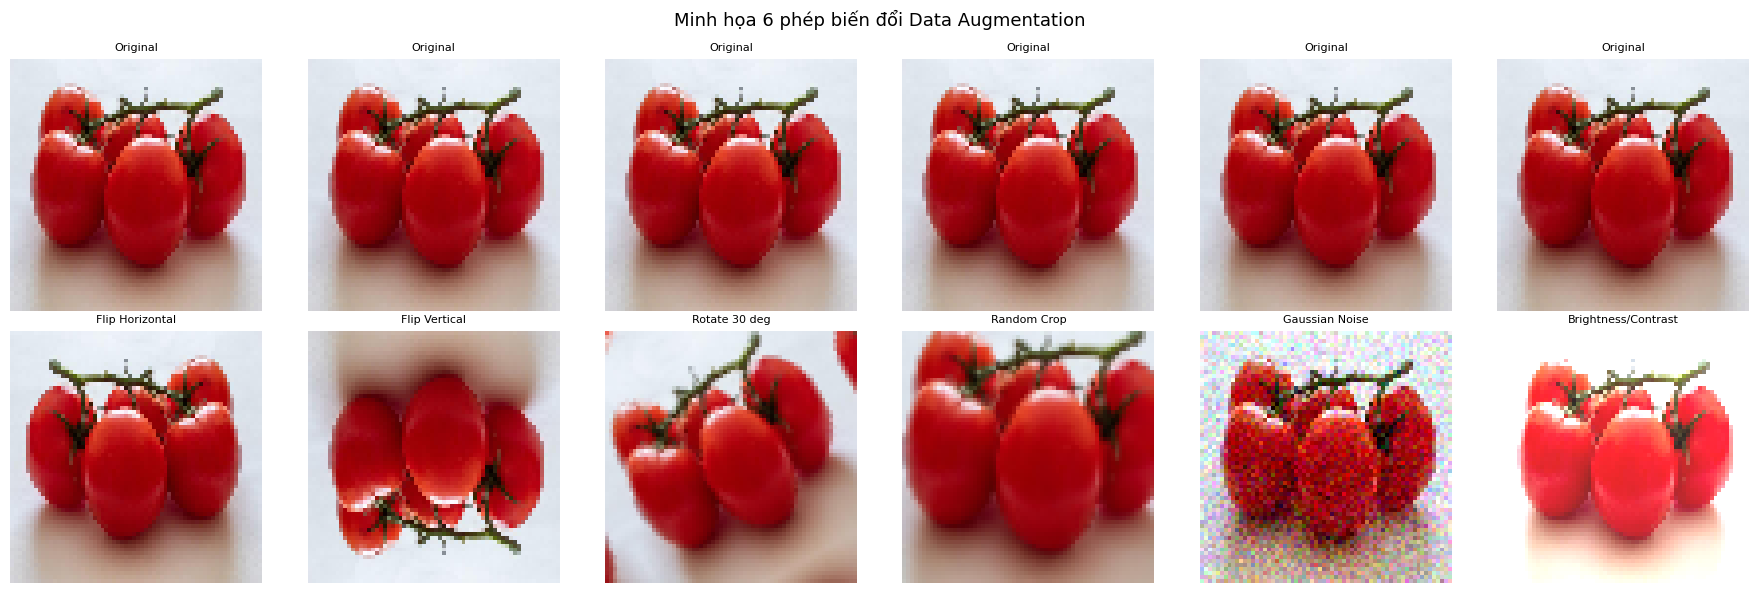

In [10]:
def aug_flip_h(img): return cv2.flip(img, 1)
def aug_flip_v(img): return cv2.flip(img, 0)

def aug_rotate(img, angle=30):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w,h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

def aug_random_crop(img, scale=0.8):
    h, w = img.shape[:2]
    nh, nw = int(h*scale), int(w*scale)
    top  = random.randint(0, h-nh)
    left = random.randint(0, w-nw)
    return cv2.resize(img[top:top+nh, left:left+nw], (w,h), interpolation=cv2.INTER_LINEAR)

def aug_gaussian_noise(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32)+noise, 0, 255).astype(np.uint8)

def aug_bright_contrast(img, alpha=1.3, beta=40):
    return np.clip(alpha*img.astype(np.float32)+beta, 0, 255).astype(np.uint8)

AUGMENT_FUNCS = [
    ('Flip Horizontal',     aug_flip_h),
    ('Flip Vertical',       aug_flip_v),
    ('Rotate 30 deg',       aug_rotate),
    ('Random Crop',         aug_random_crop),
    ('Gaussian Noise',      aug_gaussian_noise),
    ('Brightness/Contrast', aug_bright_contrast),
]

# --- Load sample images ---
AUG_SIZE = (64, 64)
N_AUG = 500
np.random.seed(42); random.seed(42)
aug_sampled_paths = np.random.choice(train_paths + val_paths + test_paths, min(N_AUG, len(train_paths + val_paths + test_paths)), replace=False).tolist()

orig_imgs_aug, orig_labels_aug = [], []
for p in aug_sampled_paths:
    img = cv2.imread(p)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, AUG_SIZE)
    orig_imgs_aug.append(img)
    orig_labels_aug.append(os.path.basename(os.path.dirname(p)))
orig_imgs_aug   = np.array(orig_imgs_aug,   dtype=np.uint8)
orig_labels_aug = np.array(orig_labels_aug)

n_orig_aug   = len(orig_imgs_aug)
n_class_aug  = len(np.unique(orig_labels_aug))
print(f'Số ảnh gốc: {n_orig_aug},  Số lớp: {n_class_aug}')

# --- Create augmented images ---
aug_imgs_d, aug_names_d = [], []
for img in orig_imgs_aug:
    name, func = random.choice(AUGMENT_FUNCS)
    aug_imgs_d.append(func(img.copy()))
    aug_names_d.append(name)
aug_imgs_d = np.array(aug_imgs_d, dtype=np.uint8)

aug_distribution = dict(Counter(aug_names_d))
print('Augmentation distribution:')
for k,v in sorted(aug_distribution.items()): print(f'  {k:<25s}: {v}')

# --- Visualize one sample through all 6 transforms ---
sample_d = orig_imgs_aug[0]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, (name, func) in enumerate(AUGMENT_FUNCS):
    axes[0,col].imshow(sample_d); axes[0,col].set_title('Original', fontsize=8); axes[0,col].axis('off')
    axes[1,col].imshow(func(sample_d.copy())); axes[1,col].set_title(name, fontsize=8); axes[1,col].axis('off')
plt.suptitle('Minh họa 6 phép biến đổi Data Augmentation', fontsize=13)
plt.tight_layout(); plt.show()

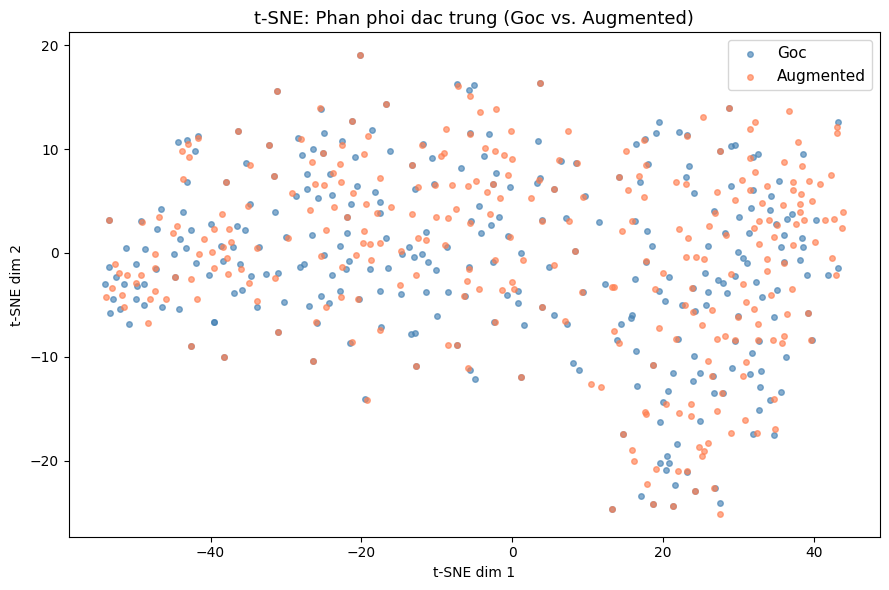

ks_stat_aug_tsne = 0.0442
p_val_aug_tsne   = 0.0000e+00
Ket luan: Phan phoi khac nhau dang ke (alpha=0.05)


In [ ]:
X_orig_d = orig_imgs_aug.reshape(len(orig_imgs_aug), -1).astype(np.float32) / 255.0
X_aug_d  = aug_imgs_d.reshape(len(aug_imgs_d),   -1).astype(np.float32) / 255.0

pca_d = PCA(n_components=50, random_state=42)
X_orig_pca_d = pca_d.fit_transform(X_orig_d)
X_aug_pca_d  = pca_d.transform(X_aug_d)

X_comb_d = np.vstack([X_orig_pca_d, X_aug_pca_d])
lbl_comb = np.array(['Goc']*len(X_orig_pca_d) + ['Augmented']*len(X_aug_pca_d))

tsne_d = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne_d = tsne_d.fit_transform(X_comb_d)

plt.figure(figsize=(9, 6))
for lbl, clr in [('Goc','steelblue'),('Augmented','coral')]:
    mask = lbl_comb == lbl
    plt.scatter(X_tsne_d[mask,0], X_tsne_d[mask,1], c=clr, label=lbl, alpha=0.65, s=16)
plt.title('t-SNE: Phan phoi dac trung (Goc vs. Augmented)', fontsize=13)
plt.legend(fontsize=11); plt.xlabel('t-SNE dim 1'); plt.ylabel('t-SNE dim 2')
plt.tight_layout(); plt.show()

# KS test - luu vao bien
ks_stat_aug_tsne, p_val_aug_tsne = ks_2samp(X_orig_d.flatten(), X_aug_d.flatten())
results_aug_tsne_ks = {'KS Statistic': ks_stat_aug_tsne, 'P-value': p_val_aug_tsne}
print(f'ks_stat_aug_tsne = {ks_stat_aug_tsne:.4f}')
print(f'p_val_aug_tsne   = {p_val_aug_tsne:.4e}')
print(f'Ket luan: {"Phan phoi khac nhau dang ke" if p_val_aug_tsne < 0.05 else "Khong khac biet dang ke"} (alpha=0.05)')

### Đo lường định lượng và ablation study
**Kiểm định:** KS test so sánh phân phối đặc trưng gốc và augmented.

ab_acc_orig_only   = 0.3600 +/- 0.0356
ab_acc_with_aug    = 0.5233 +/- 0.0366
ab_improvement_pct = +16.33%


THỐNG KÊ KOLMOGOROV-SMIRNOV TEST (So sánh phân phối pixel Gốc vs Augmented):
ks_stat_aug_ab     = 0.6794
p_val_aug_ab       = 0.0000e+00
Giả thuyết H0: Phân phối mức pixel của ảnh gốc và ảnh augmented là giống nhau (không có khác biệt).
Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê về phân phối giữa hai tập ảnh.
Kết luận: p-value = 0.0000e+00 < 0.05 => BÁC BỎ giả thuyết H0.
=> Có sự khác biệt đáng kể về đặc trưng phân phối giữa ảnh gốc và ảnh đã qua Data Augmentation.
------------------------------------------------------------


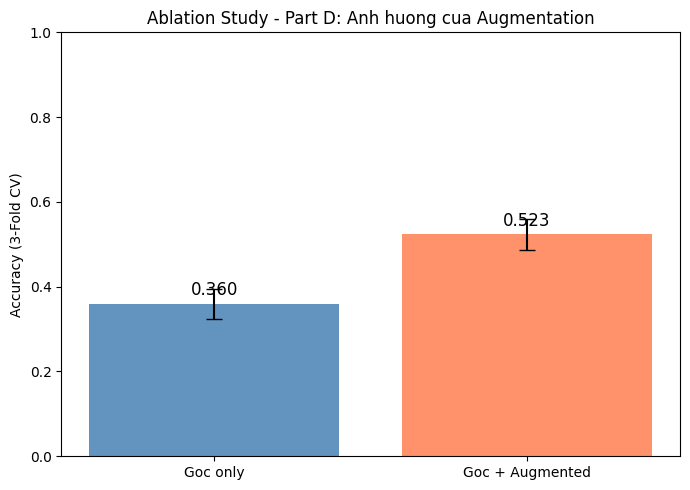

In [30]:
# Su dung data da tao o Phan D
X_orig_ab = orig_imgs_aug.reshape(len(orig_imgs_aug), -1).astype(np.float32) / 255.0
X_aug_ab  = aug_imgs_d.reshape(len(aug_imgs_d), -1).astype(np.float32) / 255.0
y_orig_ab = orig_labels_aug

# Accuracy: chi dung anh goc
ab_acc_orig_only, ab_std_orig_only = eval_lr_pca(X_orig_ab, y_orig_ab)

# Accuracy: goc + augmented gop lai
X_comb_ab = np.vstack([X_orig_ab, X_aug_ab])
y_comb_ab = np.concatenate([y_orig_ab, y_orig_ab])
ab_acc_with_aug, ab_std_with_aug = eval_lr_pca(X_comb_ab, y_comb_ab)

# Ty le cai thien
ab_improvement_pct = (ab_acc_with_aug - ab_acc_orig_only) * 100

# KS test
ks_stat_aug_ab, p_val_aug_ab = ks_2samp(
    X_orig_ab.flatten()[:5000],
    X_aug_ab.flatten()[:5000])

print(f'ab_acc_orig_only   = {ab_acc_orig_only:.4f} +/- {ab_std_orig_only:.4f}')
print(f'ab_acc_with_aug    = {ab_acc_with_aug:.4f} +/- {ab_std_with_aug:.4f}')
print(f'ab_improvement_pct = {ab_improvement_pct:+.2f}%\n')

print()
print('THỐNG KÊ KOLMOGOROV-SMIRNOV TEST (So sánh phân phối pixel Gốc vs Augmented):')
print(f'ks_stat_aug_ab     = {ks_stat_aug_ab:.4f}')
print(f'p_val_aug_ab       = {p_val_aug_ab:.4e}')
alpha_aug = 0.05
print("Giả thuyết H0: Phân phối mức pixel của ảnh gốc và ảnh augmented là giống nhau (không có khác biệt).")
print("Giả thuyết H1: Có sự khác biệt có ý nghĩa thống kê về phân phối giữa hai tập ảnh.")
if p_val_aug_ab < alpha_aug:
    print(f'Kết luận: p-value = {p_val_aug_ab:.4e} < {alpha_aug} => BÁC BỎ giả thuyết H0.')
    print("=> Có sự khác biệt đáng kể về đặc trưng phân phối giữa ảnh gốc và ảnh đã qua Data Augmentation.")
else:
    print(f'Kết luận: p-value = {p_val_aug_ab:.4e} >= {alpha_aug} => KHÔNG BÁC BỎ giả thuyết H0.')
    print("=> Không đủ bằng chứng thống kê để cho thấy sự khác biệt về phân phối giữa hai tập ảnh.")
print('-'*60)

plt.figure(figsize=(7,5))
lbl_d2 = ['Goc only', 'Goc + Augmented']
acc_d2 = [ab_acc_orig_only, ab_acc_with_aug]
std_d2 = [ab_std_orig_only, ab_std_with_aug]
bars_d = plt.bar(lbl_d2, acc_d2, yerr=std_d2, capsize=6,
                 color=['steelblue','coral'], alpha=0.85)
plt.ylim(0,1); plt.title('Ablation Study - Part D: Anh huong cua Augmentation'); plt.ylabel('Accuracy (3-Fold CV)')
for b,a in zip(bars_d,acc_d2): plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{a:.3f}', ha='center', fontsize=12)
plt.tight_layout(); plt.show()

## (iii) Phân tích kết quả
- **Sự đa dạng của hình ảnh sinh ra**: Thông qua phần biểu diễn ảnh gốc và ảnh Augmented kế bên nhau, rõ ràng pipeline 5 bước đã giả lập thành công các tình huống thực tế của trái cây với góc độ, độ thu phóng, lỗi cảm biến điện tử và các hướng sáng yếu mạnh khác nhau. Điều này khiến cho tập train dữ liệu trở nên phân mảnh biến thể phong phú.
- **Tác động đến phân phối đặc trưng (Quan sát t-SNE)**:
  - Trên biểu đồ phân tán **t-SNE**, các điểm xanh (Original) là bộ xương đại diện cho khối cấu trúc dữ liệu ban đầu.
  - Các điểm cam (Augmented) nằm bao phủ (overlap) và lan rộng (extend) tại các vùng rìa phân mảnh của các cụm màu xanh.
  - Sự giao thoa (overlap) gần của điểm màu cam mang ý nghĩa việc tăng cường **đang khuếch đại hợp lệ và bảo toàn cấu trúc nhận diện**. Các điểm mở rộng ra ngoài là các biên độ biến thể mô phỏng một thế giới mở có tính tổng quát cao, giúp mô hình bớt bám chặt (memorize - overfitting) vào các điểm xanh cụ thể nguyên thủy. Nó lấp lỗ hổng trong bản đồ không gian và tăng độ phong phú vùng quyết định (decision boundary) cho Machine Learning Model.